# Movement: Segmentation Mask Interaction Analysis (PoC)

This notebook demonstrates a proof-of-concept for integrating dense segmentation masks into the `movement` library. We use tracking data from OCTRON to lazily load masks, compute physical proximity using morphological dilation, and visualize the temporal and spatial interactions.

In [1]:
import numpy as np
import xarray as xr
import dask.array as da
import scipy.ndimage as ndi
import matplotlib.pyplot as plt

### 1. Lazy Data Loading
We use Dask to lazily load the Zarr arrays, ensuring memory efficiency before wrapping them into a unified `xarray.Dataset`.

In [2]:
mask1_path = "octron-mouse-interaction/681fa921/mouse_1 masks.zarr"
mask2_path = "octron-mouse-interaction/681fa921/mouse_2 masks.zarr"

stacked_masks = da.stack([
    da.from_zarr(mask1_path, component="masks"),
    da.from_zarr(mask2_path, component="masks")
], axis=1)

ds = xr.Dataset(
    {"masks": (["time", "individuals", "x", "y"], stacked_masks)},
    coords={
        "time": np.arange(stacked_masks.shape[0]), 
        "individuals": ["mouse_1", "mouse_2"]
    }
)

### 2. Proximity Calculation
In 2D top-down tracking, visual occlusion prevents exact pixel intersection. We apply morphological dilation to create a proximity boundary around the first subject to accurately detect physical interaction.

In [3]:
def compute_proximity_area(data, ind1, ind2, mask_var="masks", tolerance=15):
    """Calculates interaction area by expanding the first mask to account for 2D occlusion."""
    masks = data[mask_var]
    
    mask_a = masks.sel(individuals=ind1).compute().values > 0
    mask_b = masks.sel(individuals=ind2).compute().values > 0
    
    temporal_struct = np.zeros((1, 3, 3), dtype=bool)
    temporal_struct[0, :, :] = True
    
    expanded_a = ndi.binary_dilation(mask_a, structure=temporal_struct, iterations=tolerance)
    interaction = expanded_a & mask_b
    
    contact_area = interaction.astype(np.float64).sum(axis=(1, 2))
    
    return xr.DataArray(
        contact_area,
        dims=["time"],
        coords={"time": data.coords["time"]}
    )

### 3. Execution & Peak Detection
Calculate the proximity timeline and identify the frame with the maximum interaction.

In [4]:
tolerance = 15

contact_areas = compute_proximity_area(ds, "mouse_1", "mouse_2", tolerance=tolerance)

peak_frame = int(contact_areas.argmax(dim="time").item())
peak_area = contact_areas.max().item()

print(f"Peak interaction: Frame {peak_frame} ({peak_area} px)")

Peak interaction: Frame 649 (1176.0 px)


### 4. Spatial Verification
Render a composite image of the peak frame to visually verify the interaction zone.

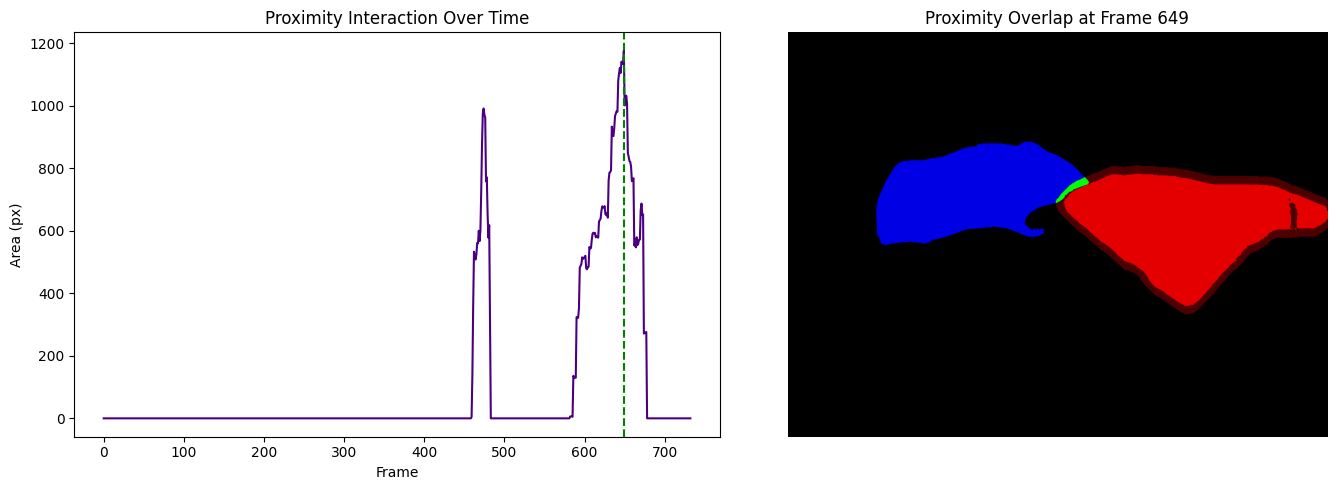

In [5]:
mask1 = ds.masks.sel(time=peak_frame, individuals="mouse_1").compute().values > 0
mask2 = ds.masks.sel(time=peak_frame, individuals="mouse_2").compute().values > 0

mask1_expanded = ndi.binary_dilation(mask1, iterations=tolerance)
interaction_zone = mask1_expanded & mask2
aura_only = mask1_expanded & ~mask1

h, w = mask1.shape
composite = np.zeros((h, w, 3), dtype=np.float32)

composite[mask1] = [0.9, 0.0, 0.0]
composite[aura_only] = [0.3, 0.0, 0.0]
composite[mask2] = [0.0, 0.0, 0.9]
composite[interaction_zone] = [0.0, 1.0, 0.0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(contact_areas.time, contact_areas.values, color='indigo')
axes[0].axvline(x=peak_frame, color='green', linestyle='--')
axes[0].set(title="Proximity Interaction Over Time", xlabel="Frame", ylabel="Area (px)")

axes[1].imshow(composite)
axes[1].set(title=f"Proximity Overlap at Frame {peak_frame}")
axes[1].axis('off')

plt.tight_layout()
plt.show()